In [1]:
from typing import TypedDict, List,Annotated
from pydantic import BaseModel, Field
import operator
from langgraph.graph import StateGraph,END,START
from langgraph.types import Send
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage

import psycopg
from psycopg.rows import dict_row
from langgraph.checkpoint.postgres import PostgresSaver
from dotenv import load_dotenv

load_dotenv()

c:\Users\avinash.polisetty\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
def get_database_url():
    database_url = os.getenv("DATABASE_URL")
    if not database_url:
        raise ValueError("DATABASE_URL environment variable is not set.")

    if 'sslmode=' not in database_url:
        separator = "&" if "?" in database_url else "?"
        database_url = f"{database_url}{separator}sslmode=require"

    return database_url 

In [3]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [4]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [5]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [6]:
llm = ChatGoogleGenerativeAI(
        model=os.getenv("GEMINI_MODEL"),
        temperature=0.2,
        
    )

llm

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.5.2', 'langchain': '0.3.24'}}, output_version=None, model='models/gemini-3.5-flash-lite', google_api_key=SecretStr('**********'), temperature=0.2, client=<google.ai.generativelanguage_v1beta.services.generative_service.client.GenerativeServiceClient object at 0x0000021F253482F0>, default_metadata=(), model_kwargs={})

In [7]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [8]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [9]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [10]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [11]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

In [12]:
DATABASE_URL = get_database_url()

_conn = psycopg.connect(
    DATABASE_URL,
    autocommit=True,
    row_factory=dict_row
)

checkpointer = PostgresSaver(_conn)
checkpointer.setup()

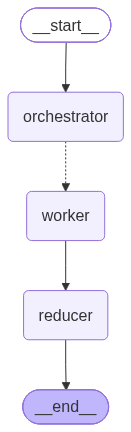

In [14]:
graph = g.compile(checkpointer=checkpointer)
graph

In [15]:
config = {
    'configurable' : {"thread_id" : "thread_1"}
}

In [17]:
res = graph.invoke({"topic": "write a blog on muse spark","sections" : []}, config= config)




KeyboardInterrupt: 

In [51]:


def reverse(arr):
    left = 0
    right = len(arr) -1

    while left < right:
        arr[left],arr[right] = arr[right],arr[left]

        left += 1
        right -= 1  
    return arr

arr1 = [1,2,3,4,5]

print(reverse(arr1))
    

[5, 4, 3, 2, 1]


In [56]:
def reverse(arr):
    left = 0
    right = len(arr) - 1

    while left < right:

        arr[left],arr[right] = arr[right],arr[left]
        
        left += 1
        right -= 1
    return arr




arr = [1,2,3,4,5]
print(reverse(arr))

[5, 4, 3, 2, 1]


In [83]:
def sort(arr):

    n = len(arr)

    for i in range(n):
        for j in range(0,n-i-1):
            if arr[j] > arr[j+1]:
                arr[j],arr[j+1] = arr[j+1],arr[j]

    return arr

arr = [33,1,2,3,4,5,332,4,5,56]
print(sort(arr))

[1, 2, 3, 4, 4, 5, 5, 33, 56, 332]


In [92]:
def second_largest(arr):

    if len(arr) < 2:
        return None

    first = float('-inf')
    second = float('-inf')

    for i in arr:
        if i > first:
            second = first
            first = i

        elif i > second and i != first:
            second = i

    return second

nums = [35,35,34]
print(second_largest(nums))



34


1